# Pipeline Medalhão Local — Bronze → Silver → Gold

**Tech Challenge Fase 3 — POSTECH AI Scientist**

Este notebook executa e documenta a **frente de Engenharia de Dados** da entrega: a
reconstrução, em Python puro e sem AWS, da arquitetura medalhão desenvolvida na Fase 2,
agora estendida com as **fontes externas de enriquecimento** exigidas pelo Tech Challenge.

---

### Por que refazer a pipeline em vez de só consumir a Gold da Fase 2?

O enunciado pede que os dados venham da camada Gold da Fase 2. Ocorre que aquela Gold foi
desenhada para **análise descritiva** (gap de meta, ranking, evolução), não para modelagem:
suas colunas mais informativas são justamente as que **vazam o alvo**. Reconstruir a pipeline
permite três coisas que consumir o Parquet pronto não permitiria:

1. **integrar as fontes externas** (Censo Escolar, INSE, IDEB) já na Silver e na Gold, com as
   mesmas regras de qualidade das bases originais — sem isso sobrariam ~4 features legítimas;
2. **materializar o tratamento de leakage na camada de dados**, e não dentro do notebook de
   modelagem, deixando a decisão auditável no repositório;
3. rodar tudo **localmente e de graça**, o que torna a entrega reproduzível por qualquer
   avaliador (`python -m src.preprocessing.run_pipeline`) sem provisionar infraestrutura.

### O que muda em relação à Fase 2

| | Fase 2 | Fase 3 |
|---|---|---|
| Execução | AWS Glue (PySpark) + S3 + Athena | pandas + Parquet em disco local |
| Entidades | 5 CSVs do INEP | 5 CSVs + 5 entidades externas |
| Gold | 4 visões descritivas | as mesmas 4 + `base_ml_alfabetizacao` |
| Objetivo | disponibilizar dado confiável | disponibilizar dado **modelável** |

O que **não** muda: schema explícito, hash de deduplicação, DQ com quarentena, particionamento
Hive-style por ano e escrita idempotente. A semântica da arquitetura é a mesma; só o motor
mudou.

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# O notebook vive em notebooks/; os módulos da pipeline, em src/.
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

from src.preprocessing import (
    run_bronze, run_silver, run_gold,
    carregar_base_ml, snapshot_camada, comparar_snapshots, ler_particionado,
)
from src.preprocessing import config as cfg

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)

print("Raiz do projeto :", RAIZ)
print("Dados de origem :", cfg.DADOS_DIR)
print("Data lake local :", cfg.LAKE_DIR)

Raiz do projeto : C:\Development\1IAST-Fase3
Dados de origem : C:\Development\1IAST-Fase3\data
Data lake local : C:\Development\1IAST-Fase3\data\lake


---

## 1. Camada Bronze (SOR) — ingestão fiel e rastreável

A Bronze é a **fonte da verdade do que chegou**. A regra que a governa é: *nada é corrigido,
nada é descartado*. Ela apenas:

| Etapa | O que faz | Por quê |
|---|---|---|
| Schema explícito | tipagem declarada na leitura | `id_municipio` é um código IBGE de **7 dígitos**; inferido como inteiro, perderia o zero à esquerda e quebraria todos os joins |
| `_record_hash` | MD5 da chave de negócio | insumo da deduplicação na Silver — a duplicata é **contabilizada**, não some na leitura |
| Linhagem | `_ingestion_timestamp`, `_source_entity` | permite reconduzir qualquer linha da base analítica à origem |
| Checks FAIL/WARN | validações com score % | `FAIL` interrompe a ingestão; `WARN` registra e segue |
| Partição `ano=YYYY` | escrita Hive-style | reprocessar um ciclo não toca os demais (*overwrite dinâmico*) |

**Decisão de projeto:** as cinco entidades externas entram na Bronze **na granularidade
original** — todas as fatias de localização e dependência administrativa do Censo, todas as
duplicatas do INSE, todos os 11 ciclos do IDEB. Filtrar na ingestão economizaria espaço, mas
destruiria a rastreabilidade e esconderia problemas de qualidade que precisamos medir.

**Uma transformação é feita já na Bronze, por necessidade física:** o arquivo do IDEB vem em
formato **largo** (uma coluna por métrica × ciclo: `VL_OBSERVADO_2005`, `VL_OBSERVADO_2007`,
...). Sem convertê-lo para o formato **longo** não existe coluna `ano` — e `ano` é a chave de
partição do lake.

In [2]:
sumario_bronze = run_bronze(verbose=False)
sumario_bronze

,entidade,registros,anos,hashes_distintos,score_dq
0,indicador_municipio,23995,"[2023, 2024]",23995,100.0
1,indicador_uf,145,"[2023, 2024]",145,100.0
2,meta_brasil,3,"[2023, 2024, 2025]",3,100.0
3,meta_uf,54,"[2023, 2024]",54,100.0
4,meta_municipio,10704,"[2023, 2024]",10704,100.0
5,censo_afd,134233,"[2023, 2024]",134233,100.0
6,censo_atu,132605,"[2023, 2024]",132605,100.0
7,censo_ied,132590,"[2023, 2024]",132590,100.0
8,inse,125741,[2023],71576,100.0
9,ideb_anos_iniciais,159687,"[2005, 2007, 2009, 2011, 2013, 2015, 2017, 201...",159687,100.0


**Leitura do resultado.** Todas as 10 entidades passaram nos checks com score 100%. Dois pontos
merecem atenção:

- **`inse`**: 125.741 registros lidos, mas apenas **71.576 hashes distintos**. O arquivo do INEP
  repete a mesma chave `município × rede × localização` até 7 vezes. A Bronze registra o fato;
  a Silver o resolve.
- **`ideb_anos_iniciais`**: 159.687 linhas cobrindo **11 ciclos, de 2005 a 2025** — resultado do
  despivotamento. Só o ciclo de 2021 será usado, mas o histórico fica disponível no lake para
  análises futuras (custo marginal: alguns MB em Parquet).

In [3]:
def listar_particoes(camada, limite=12):
    "Mostra a estrutura física de partições gravada no lake."
    base = cfg.LAKE_DIR / camada
    linhas = []
    for particao in sorted(base.rglob("ano=*")):
        arquivo = particao / "dados.parquet"
        if arquivo.exists():
            linhas.append({
                "particao": str(particao.relative_to(cfg.LAKE_DIR)).replace("\\", "/"),
                "linhas": len(pd.read_parquet(arquivo)),
                "kb": round(arquivo.stat().st_size / 1024, 1),
            })
    df = pd.DataFrame(linhas)
    print(f"{len(df)} partições físicas em {camada}/ — {df['kb'].sum()/1024:.1f} MB no total")
    return df.head(limite)


listar_particoes("bronze")

29 partições físicas em bronze/ — 29.3 MB no total


,particao,linhas,kb
0,bronze/censo_afd/ano=2023,67134,2539.9
1,bronze/censo_afd/ano=2024,67099,2535.0
2,bronze/censo_atu/ano=2023,66336,2538.1
3,bronze/censo_atu/ano=2024,66269,2536.8
4,bronze/censo_ied/ano=2023,66313,2595.8
5,bronze/censo_ied/ano=2024,66277,2592.5
6,bronze/ideb_anos_iniciais/ano=2005,14517,705.4
7,bronze/ideb_anos_iniciais/ano=2007,14517,774.9
8,bronze/ideb_anos_iniciais/ano=2009,14517,772.9
9,bronze/ideb_anos_iniciais/ano=2011,14517,760.4


---

## 2. Camada Silver (SOT) — limpeza, deduplicação e quarentena

A Silver é onde o dado passa a ser **confiável**. Três operações, nesta ordem:

**1. Deduplicação pelo `_record_hash`.** A chave de negócio já foi hasheada na Bronze; aqui
basta `drop_duplicates`. Como o hash é determinístico, o resultado independe da ordem de
leitura — condição para a idempotência que provamos na seção 6.

**2. Padronização.** Decode dos domínios codificados (`rede` 0/2/3/5 → total/estadual/municipal/
privada; `TP_TIPO_REDE` e `TP_LOCALIZACAO` do INSE conforme a aba *Dicionário* do próprio
arquivo), coerção de tipos e arredondamentos.

**3. Regras de qualidade como colunas booleanas `_dq_*`**, consolidadas em `_dq_passou`.
Materializar a regra como coluna — em vez de filtrar direto — é o que permite o passo seguinte.

### Por que quarentena e não descarte

Registro reprovado **não é jogado fora**: vai para `silver/quarentena/` com
`_quarentena_motivo` preenchido pela concatenação de todas as regras que ele violou. Isso
sustenta três coisas: auditoria (*por que este município sumiu da análise?*), reprocesso
(quando a origem corrigir o dado) e medição de qualidade ao longo do tempo.

A quarentena é particionada por **data de processamento** (`anomesdia=YYYYMMDD`), não por `ano`
— porque o `ano` pode ser exatamente o campo inválido que causou a reprovação.

In [4]:
sumario_silver = run_silver(verbose=False)
sumario_silver

,entidade,lidos_bronze,duplicados_removidos,pass,quarentena,score_dq
0,indicador_municipio,23995,0,23995,0,100.0
1,indicador_uf,145,0,145,0,100.0
2,meta_brasil,3,0,3,0,100.0
3,meta_uf,54,0,54,0,100.0
4,meta_municipio,10704,0,10704,0,100.0
5,censo_afd,134233,0,134233,0,100.0
6,censo_atu,132605,0,132605,0,100.0
7,censo_ied,132590,0,132590,0,100.0
8,inse,125741,54165,70686,890,98.8
9,ideb_anos_iniciais,159687,0,159687,0,100.0


**Leitura do resultado.** Nove das dez entidades passam limpas: zero duplicatas, zero
quarentena, score 100%. Toda a ação está no INSE:

- **54.165 linhas duplicadas removidas** — 43% do arquivo original;
- **890 registros em quarentena**, score 98,8%.

Este é exatamente o retorno de ter guardado a duplicata na Bronze: ela virou um **número
auditável** em vez de desaparecer silenciosamente num `drop_duplicates` escondido na leitura.
Se tivéssemos deduplicado na ingestão, o relatório de qualidade diria "100% em tudo" e a
fragilidade da fonte ficaria invisível.

Vale notar o risco concreto que a deduplicação evitou: sem ela, o join do INSE com a base do
indicador **multiplicaria** as linhas de cada município por até 7 — inflando artificialmente a
base de treino e enviesando o modelo em favor dos municípios duplicados.

In [5]:
# O que exatamente foi para a quarentena do INSE?
quarentena_inse = pd.concat([
    pd.read_parquet(p)
    for p in (cfg.LAKE_DIR / "silver" / "quarentena" / "inse").rglob("*.parquet")
])

print("Motivos de reprovação:")
display(quarentena_inse["_quarentena_motivo"].value_counts().rename("registros").to_frame())

print("\nAmostra dos registros reprovados:")
quarentena_inse[["id_municipio", "tipo_rede", "localizacao",
                 "qtd_alunos_inse", "media_inse", "_quarentena_motivo"]].head()

Motivos de reprovação:


,registros
_quarentena_motivo,
"media_inse nula ou fora da escala [0, 10]",890



Amostra dos registros reprovados:


,id_municipio,tipo_rede,localizacao,qtd_alunos_inse,media_inse,_quarentena_motivo
0,1100049,4,1,389,NaN,"media_inse nula ou fora da escala [0, 10]"
1,1100049,4,2,11,NaN,"media_inse nula ou fora da escala [0, 10]"
2,1101807,4,2,28,NaN,"media_inse nula ou fora da escala [0, 10]"
3,1101492,4,2,14,NaN,"media_inse nula ou fora da escala [0, 10]"
4,1100403,4,1,22,NaN,"media_inse nula ou fora da escala [0, 10]"


Os 890 registros reprovados são estratos com `media_inse` ausente — tipicamente municípios com
pouquíssimos alunos no estrato, onde o INEP **omite o indicador por sigilo estatístico**. Não é
erro de dado: é ausência legítima. Mantê-los na base introduziria um `NaN` numa variável que o
modelo trata como contínua, então eles ficam registrados na quarentena, com o motivo explícito.

---

## 3. Camada Gold (SPEC) — visões analíticas e base de modelagem

A Gold entrega dado **pronto para consumo**. São cinco visões:

| Visão | Origem | Papel |
|---|---|---|
| `alfabetizacao_por_municipio` | Fase 2 | KPI municipal com gap e status da meta 2025 |
| `evolucao_temporal` | Fase 2 | agregações estatísticas por UF/ano |
| `ranking_municipios` | Fase 2 | posição do município dentro da própria UF |
| `comparacao_metas_nacionais` | Fase 2 | taxa por UF × meta nacional × meta estadual |
| **`base_ml_alfabetizacao`** | **Fase 3** | **tabela analítica do modelo supervisionado** |

As quatro primeiras são reproduzidas fielmente para manter a continuidade com a Fase 2 e
continuam servindo à análise descritiva. A quinta é a entrega desta fase.

### O grão da base de modelagem, e por que ele é este

**Município × ano, restrito à rede municipal (código 3), nos ciclos 2023 e 2024.**

A restrição à rede municipal não é arbitrária. A tabela abaixo mostra a cobertura por rede e
ano no arquivo do indicador:

| ano | rede 0 (total) | 2 (estadual) | 3 (municipal) | 5 (privada) |
|---|---:|---:|---:|---:|
| 2023 | — | 1.149 | **5.448** | 4.950 |
| 2024 | 398 | 1.086 | **5.448** | 5.516 |

A rede municipal é a **única com cobertura idêntica nos dois ciclos** — condição para um split
temporal 2023 → 2024 sem viés de composição. A rede *total* só existe em 2024, e para apenas
398 municípios. Além disso, é a rede sob gestão direta do município, que é o destinatário das
recomendações de política pública que o projeto pretende produzir.

In [6]:
sumario_gold = run_gold(verbose=False)
sumario_gold

,visao,registros,colunas,anos
0,alfabetizacao_por_municipio,10896,12,"[2023, 2024]"
1,evolucao_temporal,49,9,"[2023, 2024]"
2,ranking_municipios,10896,10,"[2023, 2024]"
3,comparacao_metas_nacionais,49,10,"[2023, 2024]"
4,base_ml_alfabetizacao,10896,39,"[2023, 2024]"


---

## 4. A base de modelagem

`base_ml_alfabetizacao` combina quatro blocos de informação, cada um com uma natureza temporal
diferente — e essa diferença importa para o tratamento de leakage:

| Bloco | Fonte | Temporalidade |
|---|---|---|
| Território | derivado do código IBGE | estático |
| Docentes e turmas (AFD, ATU, IED) | Censo Escolar | **por ano** (2023 e 2024) |
| Socioeconômico (INSE) | Saeb 2023 | estrutural — replicado para 2024 |
| Desempenho pregresso (IDEB) | ciclo **2021** | **defasado**, anterior ao alvo |

**Sobre a replicação do INSE:** o indicador só existe para 2023. Tratá-lo como atributo
estrutural do município é defensável — nível socioeconômico não muda de forma relevante em um
ciclo — mas é uma simplificação, e está declarada nas limitações do projeto.

**Sobre a proporção rural:** ela não vem do Censo (AFD/ATU/IED trazem só percentuais e médias,
sem contagem de matrículas), e sim do INSE, que traz `QTD_ALUNOS_INSE` por localização:
`alunos(rural) / alunos(total)` na rede municipal. Município sem linha rural tem proporção
**0** — ausência estrutural de oferta, não dado faltante.

In [7]:
base = carregar_base_ml().drop(columns=["_gold_processed_at"])

print(f"Grão: município × ano | {base.shape[0]} linhas × {base.shape[1]} colunas")
print(f"Municípios: {base['id_municipio'].nunique()} | Anos: {sorted(base['ano'].unique())}")
base.head()

Grão: município × ano | 10896 linhas × 38 colunas
Municípios: 5500 | Anos: [np.int64(2023), np.int64(2024)]


,id_municipio,sigla_uf,regiao,taxa_alfabetizacao,afd_ai_grupo_1,afd_ai_grupo_2,afd_ai_grupo_3,afd_ai_grupo_4,afd_ai_grupo_5,atu_creche,atu_pre_escola,atu_anos_iniciais,atu_1_ano,atu_2_ano,ied_ai_nivel_1,ied_ai_nivel_2,ied_ai_nivel_3,ied_ai_nivel_4,ied_ai_nivel_5,ied_ai_nivel_6,media_inse,qtd_alunos_inse,capital_desc,inse_pc_nivel_1,inse_pc_nivel_2,inse_pc_nivel_3,inse_pc_nivel_4,inse_pc_nivel_5,inse_pc_nivel_6,inse_pc_nivel_7,inse_pc_nivel_8,proporcao_rural,ideb_2021,nota_portugues_2021,nota_matematica_2021,indicador_rendimento_2021,taxa_aprovacao_2021,ano
0,1100015,RO,Norte,64.55,67.5,0.0,0.0,2.2,30.3,14.5,20.0,15.2,16.2,17.8,91.2,2.5,0.0,6.3,0.0,0.0,5.0060,281.0,interior,0.00,5.72,17.13,31.25,25.25,13.22,6.18,1.25,0.1459,4.8,181.93,191.69,0.979422,97.8,2023
1,1100023,RO,Norte,62.30,84.1,1.4,11.4,0.6,2.5,19.9,24.0,23.3,22.2,23.4,32.9,21.0,24.1,20.1,1.3,0.6,4.8507,1141.0,interior,0.26,9.54,20.98,29.27,24.30,9.91,5.32,0.41,0.2165,4.5,189.83,200.35,0.866519,87.2,2023
2,1100031,RO,Norte,69.10,100.0,0.0,0.0,0.0,0.0,43.5,16.0,14.2,14.7,13.0,89.3,7.1,3.6,0.0,0.0,0.0,5.2758,49.0,interior,0.00,0.00,14.38,24.67,28.43,14.05,16.34,2.12,0.0000,5.1,190.63,207.16,0.939656,94.9,2023
3,1100049,RO,Norte,62.51,83.2,1.5,7.3,1.8,6.2,14.1,17.3,20.8,22.0,22.4,27.6,17.7,29.4,23.0,1.5,0.8,4.9364,735.0,interior,0.00,6.91,17.50,31.92,25.21,11.94,5.52,1.01,0.4014,5.6,202.35,208.39,0.998998,99.9,2023
4,1100056,RO,Norte,58.53,90.2,0.0,8.2,1.6,0.0,12.2,19.1,20.9,21.6,21.3,73.0,11.1,6.3,4.8,3.2,1.6,4.9469,183.0,interior,0.00,9.14,14.97,28.72,26.62,14.15,5.88,0.51,0.0000,5.5,199.81,206.88,1.000000,100.0,2023


In [8]:
# Evolução do alvo entre os dois ciclos
base.groupby("ano")["taxa_alfabetizacao"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
ano,,,,,,,,
2023,5448.0,60.28,19.82,4.35,46.50,60.72,75.00,100.0
2024,5448.0,62.80,19.34,4.40,48.28,64.05,77.59,100.0


A taxa média subiu de **60,3% para 62,8%** entre 2023 e 2024 — ganho de 2,5 pontos percentuais.
A dispersão é enorme e praticamente não se altera (desvio ~19,5 p.p.), com municípios variando
de ~4% a 100%. É essa desigualdade, e não a média, que o modelo precisa explicar.

In [9]:
# Ausências por bloco — insumo direto da estratégia de imputação do notebook 03
ausencias = (base.isna().mean() * 100).round(1)
ausencias[ausencias > 0].sort_values(ascending=False).rename("% ausente").to_frame()

,% ausente
ideb_2021,13.3
nota_matematica_2021,13.3
nota_portugues_2021,13.3
indicador_rendimento_2021,5.0
taxa_aprovacao_2021,5.0
atu_creche,1.6
media_inse,0.7
inse_pc_nivel_6,0.7
inse_pc_nivel_5,0.7
inse_pc_nivel_4,0.7


**Como cada ausência será tratada — e por quê são diferentes entre si:**

| Bloco | % | Natureza | Tratamento previsto |
|---|---:|---|---|
| IDEB 2021 (`ideb_2021`, notas) | 13,3% | município sem IDEB divulgado no ciclo | imputação **com `add_indicator=True`** — a ausência é informativa |
| `indicador_rendimento_2021`, `taxa_aprovacao_2021` | 5,0% | idem | idem |
| `atu_creche` | 1,6% | município sem oferta de creche | imputação pela mediana |
| Bloco INSE completo | 0,7% | sem estrato INSE municipal em 2023 | imputação pela mediana |
| Bloco AFD | 0,1% | residual | imputação pela mediana |

A distinção importa: um município **sem IDEB divulgado** costuma ser um município pequeno e
isolado — a própria ausência carrega sinal, e apagá-la com a mediana descartaria informação.
Por isso o indicador de ausência entra como feature na pipeline do modelo.

### Um achado que mudou a base

No arquivo do INSE, o percentual de um nível **sem nenhum aluno vem em branco, não como zero**.
Isso fazia `inse_pc_nivel_8` aparecer com 43% de "ausência". A verificação abaixo mostra que,
tratando branco como zero, os oito níveis somam 100% em todas as linhas — são **zeros
estruturais**, e imputá-los pela média distorceria a distribuição socioeconômica de cada
município. O tratamento está em `gold._fatia_inse()`.

In [10]:
niveis_inse = [f"inse_pc_nivel_{i}" for i in range(1, 9)]
soma = base.loc[base["media_inse"].notna(), niveis_inse].sum(axis=1)
print("Soma dos 8 níveis do INSE (linhas com INSE presente):")
print(soma.describe().round(3).to_string())

Soma dos 8 níveis do INSE (linhas com INSE presente):
count    10821.000
mean       100.000
std          0.008
min         99.970
25%        100.000
50%        100.000
75%        100.010
max        100.030


---

## 5. Tratamento de data leakage — medido, não presumido

Este é o ponto mais delicado do projeto, e o enunciado o cobra explicitamente.

O arquivo do indicador do INEP traz colunas numéricas que parecem excelentes preditoras —
`media_portugues`, as proporções de alunos por nível de proficiência, as metas municipais. Elas
não são preditoras: são **a mesma medição que gerou o alvo**, ou derivações dela. Um modelo
treinado com essas colunas teria AUC próximo de 1 e **valor prático zero**, porque no momento
em que um gestor quisesse usá-lo — antes da avaliação acontecer — nenhuma delas existiria.

A lista de exclusão vive em `config.COLUNAS_VAZAMENTO`, com o motivo de cada uma, e é aplicada
programaticamente por `gold.montar_base_ml()`. Fica auditável no repositório em vez de depender
de alguém lembrar de excluí-la no notebook.

Abaixo, a magnitude do vazamento é **medida** sobre os dados reais.

In [11]:
indicador = ler_particionado(cfg.LAKE_DIR / "silver" / "pass" / "indicador_municipio")
indicador = indicador[indicador["rede"] == cfg.REDE_ALVO]
meta = ler_particionado(cfg.LAKE_DIR / "silver" / "pass" / "meta_municipio")

alvo = indicador["taxa_alfabetizacao"]
niveis = [f"proporcao_aluno_nivel_{i}" for i in range(9)]
com_niveis = indicador[indicador["proporcao_aluno_nivel_0"].notna()]

junto = (indicador[indicador["ano"] == 2023]
         .merge(meta[meta["ano"] == 2023], on=["id_municipio", "ano"], suffixes=("", "_m")))

evidencias = pd.DataFrame([
    {"coluna": "media_portugues",
     "correlacao_com_alvo": alvo.corr(indicador["media_portugues"]),
     "preenchimento_%": indicador["media_portugues"].notna().mean() * 100},
    {"coluna": "soma proporcao_aluno_nivel_5..8",
     "correlacao_com_alvo": com_niveis[niveis[5:]].sum(axis=1).corr(com_niveis["taxa_alfabetizacao"]),
     "preenchimento_%": indicador["proporcao_aluno_nivel_5"].notna().mean() * 100},
    {"coluna": "meta_alfabetizacao_2025",
     "correlacao_com_alvo": junto["taxa_alfabetizacao"].corr(junto["meta_alfabetizacao_2025"]),
     "preenchimento_%": meta["meta_alfabetizacao_2025"].notna().mean() * 100},
]).round(3)

evidencias

,coluna,correlacao_com_alvo,preenchimento_%
0,media_portugues,0.927,100.0
1,soma proporcao_aluno_nivel_5..8,0.986,50.0
2,meta_alfabetizacao_2025,0.966,100.0


**O que os números dizem.**

- `media_portugues` correlaciona **0,927** com o alvo. É a média na escala Saeb de Língua
  Portuguesa — exatamente a escala da qual a taxa é o percentual de alunos acima de 743 pontos.
- A soma das proporções dos níveis 5 a 8 chega a **0,986**. Vale registrar uma correção: as
  proporções **não reconstroem a taxa exatamente**, como se poderia supor — o ponto de corte de
  743 pontos cai *dentro* de um nível, não na fronteira entre dois; o erro médio é de 5,9 p.p.
  Continua sendo vazamento severo, mas por proximidade da mesma medição, não por identidade
  aritmética. Some-se a isso o fato de essas colunas só existirem para **2024** (50% de
  preenchimento), o que por si só as inviabilizaria num split temporal.
- `meta_alfabetizacao_2025` correlaciona **0,966** — como esperado, já que a meta de cada
  município é **calculada a partir da taxa observada em 2023**. Usá-la seria prever a taxa com
  uma função da própria taxa.

Um caso à parte: `meta_alfabetizacao_2030` é **100 para todo município** (a meta nacional é
alfabetização universal), logo tem variância zero e não é sequer utilizável.

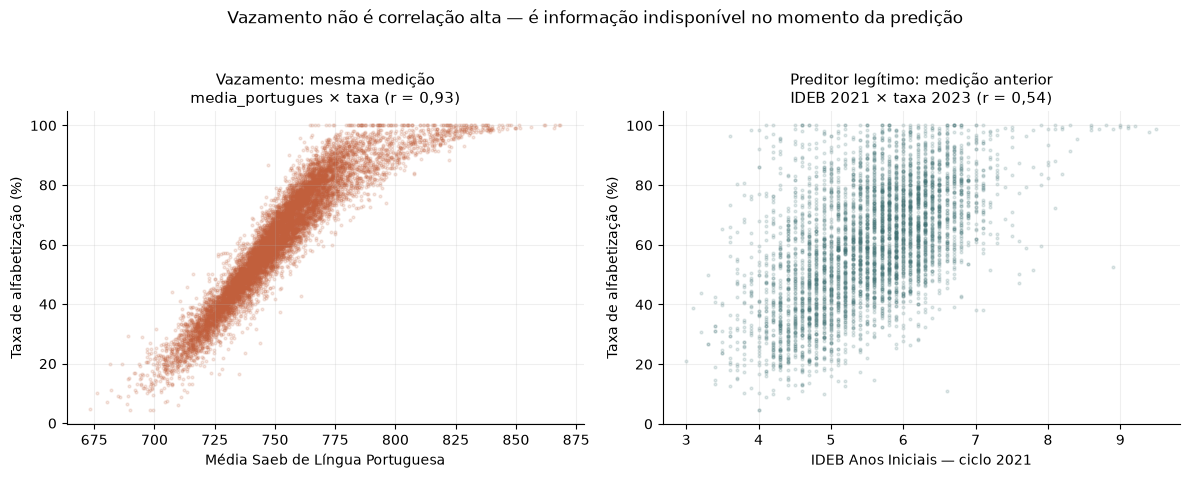

In [12]:
fig, eixos = plt.subplots(1, 2, figsize=(12, 4.6))

eixos[0].scatter(indicador["media_portugues"], indicador["taxa_alfabetizacao"],
                 s=4, alpha=0.15, color="#C15F3C")
correlacao_portugues = indicador["media_portugues"].corr(indicador["taxa_alfabetizacao"])
eixos[0].set_title(f"Vazamento: mesma medição\nmedia_portugues × taxa "
                   f"(r = {correlacao_portugues:.2f})".replace(".", ","), fontsize=11)
eixos[0].set_xlabel("Média Saeb de Língua Portuguesa")
eixos[0].set_ylabel("Taxa de alfabetização (%)")

base_2023 = base[base["ano"] == 2023]
eixos[1].scatter(base_2023["ideb_2021"], base_2023["taxa_alfabetizacao"],
                 s=4, alpha=0.15, color="#3C6E71")
correlacao_ideb = base_2023["ideb_2021"].corr(base_2023["taxa_alfabetizacao"])
eixos[1].set_title(f"Preditor legítimo: medição anterior\nIDEB 2021 × taxa 2023 "
                   f"(r = {correlacao_ideb:.2f})".replace(".", ","), fontsize=11)
eixos[1].set_xlabel("IDEB Anos Iniciais — ciclo 2021")
eixos[1].set_ylabel("Taxa de alfabetização (%)")

for eixo in eixos:
    eixo.spines[["top", "right"]].set_visible(False)
    eixo.grid(alpha=0.2)

fig.suptitle("Vazamento não é correlação alta — é informação indisponível no momento da predição",
             fontsize=12, y=1.03)
fig.tight_layout()

(RAIZ / "images").mkdir(exist_ok=True)
fig.savefig(RAIZ / "images" / "01_diagnostico_leakage.png", dpi=150, bbox_inches="tight")
plt.show()

Os dois gráficos são a síntese do critério adotado. À esquerda, `media_portugues`: correlação
altíssima porque **é a própria prova** de onde o alvo saiu — descartada. À direita, o IDEB de
2021: correlação moderada, mas trata-se de uma medição **publicada dois anos antes** do primeiro
ciclo do alvo — mantida.

O critério não é a força da correlação. É a pergunta: *esta informação estaria disponível no
momento em que a predição precisaria ser feita?*

In [13]:
# Verificação final: nenhuma coluna proibida sobreviveu até a base de modelagem.
vazamentos_presentes = [c for c in base.columns if c in cfg.COLUNAS_VAZAMENTO]

print(f"Colunas mapeadas como vazamento : {len(cfg.COLUNAS_VAZAMENTO)}")
print(f"Presentes na base de modelagem  : {len(vazamentos_presentes)}")
assert not vazamentos_presentes, f"Vazamento na base: {vazamentos_presentes}"
print("\nOK — a base de modelagem está livre das colunas mapeadas.\n")

pd.DataFrame(
    sorted(cfg.COLUNAS_VAZAMENTO.items()), columns=["coluna excluída", "motivo"]
).head(10)

Colunas mapeadas como vazamento : 23
Presentes na base de modelagem  : 0

OK — a base de modelagem está livre das colunas mapeadas.



,coluna excluída,motivo
0,gap_meta_2025,diferença entre a taxa e a meta — função diret...
1,ideb_2023,ciclo contemporâneo ao alvo — não disponível n...
2,ideb_2025,ciclo posterior aos anos do alvo — vazamento d...
3,media_portugues,mesma escala Saeb da qual a taxa é o percentua...
4,meta_alfabetizacao_2024,meta derivada aritmeticamente da taxa observad...
5,meta_alfabetizacao_2025,meta derivada aritmeticamente da taxa observad...
6,meta_alfabetizacao_2026,meta derivada aritmeticamente da taxa observad...
7,meta_alfabetizacao_2027,meta derivada aritmeticamente da taxa observad...
8,meta_alfabetizacao_2028,meta derivada aritmeticamente da taxa observad...
9,meta_alfabetizacao_2029,meta derivada aritmeticamente da taxa observad...


---

## 6. Idempotência — a pipeline pode ser reexecutada com segurança

Idempotência é a garantia de que executar a pipeline **N vezes** produz o mesmo estado final que
executá-la uma vez. Sem ela, um retry do orquestrador, uma execução interrompida ou um
reprocesso manual podem duplicar registros ou corromper partições.

A verificação compara dois *snapshots* do lake. Cada snapshot registra, por partição física, o
número de linhas e o **hash MD5 do conteúdo de negócio** — com as colunas voláteis de timestamp
(`_ingestion_timestamp`, `_gold_processed_at`, ...) removidas, e linhas e colunas ordenadas.
Isso é essencial: esses campos **mudam legitimamente** a cada execução. Idempotência se define
sobre o conteúdo de negócio, não sobre metadados de processamento.

In [14]:
snapshots_1 = {c: snapshot_camada(cfg.LAKE_DIR / c, cfg.LAKE_DIR)
               for c in ("bronze", "silver", "gold")}

# Reexecução completa sobre o mesmo insumo — simula um retry do orquestrador.
run_bronze(verbose=False)
run_silver(verbose=False)
run_gold(verbose=False)

snapshots_2 = {c: snapshot_camada(cfg.LAKE_DIR / c, cfg.LAKE_DIR)
               for c in ("bronze", "silver", "gold")}

resultado = []
for camada in snapshots_1:
    comp = comparar_snapshots(snapshots_1[camada], snapshots_2[camada])
    resultado.append({
        "camada": camada,
        "particoes": len(comp),
        "identicas": int(comp["idempotente"].sum()),
        "idempotente": bool(comp["idempotente"].all()),
    })

pd.DataFrame(resultado)

,camada,particoes,identicas,idempotente
0,bronze,29,29,True
1,silver,30,30,True
2,gold,10,10,True


In [15]:
# Detalhe partição a partição da camada Gold
comparar_snapshots(snapshots_1["gold"], snapshots_2["gold"])[
    ["particao", "n_linhas_exec1", "n_linhas_exec2", "idempotente"]
]

,particao,n_linhas_exec1,n_linhas_exec2,idempotente
0,gold/alfabetizacao_por_municipio/ano=2023,5448,5448,True
1,gold/alfabetizacao_por_municipio/ano=2024,5448,5448,True
2,gold/base_ml_alfabetizacao/ano=2023,5448,5448,True
3,gold/base_ml_alfabetizacao/ano=2024,5448,5448,True
4,gold/comparacao_metas_nacionais/ano=2023,24,24,True
5,gold/comparacao_metas_nacionais/ano=2024,25,25,True
6,gold/evolucao_temporal/ano=2023,24,24,True
7,gold/evolucao_temporal/ano=2024,25,25,True
8,gold/ranking_municipios/ano=2023,5448,5448,True
9,gold/ranking_municipios/ano=2024,5448,5448,True


Todas as partições das três camadas são idênticas entre as duas execuções: mesma estrutura,
mesma contagem e mesmo hash de conteúdo. A pipeline é segura para retry e reprocesso.

O mecanismo que garante isso é o **overwrite dinâmico por partição** (`lake.escrever_particionado`),
que reproduz o `partitionOverwriteMode=dynamic` do Spark usado na Fase 2: reprocessar o ciclo de
2024 sobrescreve apenas `ano=2024/` e preserva `ano=2023/`.

---

## Conclusão

A pipeline medalhão da Fase 2 foi reproduzida localmente, sem AWS, e estendida com cinco fontes
externas de enriquecimento. Em números:

| Camada | Resultado |
|---|---|
| **Bronze** | 10 entidades ingeridas, ~850 mil registros, score de DQ 100% |
| **Silver** | 54.165 duplicatas removidas e 890 registros em quarentena — todos do INSE |
| **Gold** | 5 visões, entre elas a `base_ml_alfabetizacao` com 10.896 linhas × 38 colunas |
| **Idempotência** | verificada nas três camadas, partição a partição |

O que a base entrega para a etapa de modelagem: **5.448 municípios × 2 ciclos**, na rede
municipal, com ~30 features legítimas cobrindo formação docente, tamanho de turma, esforço
docente, nível socioeconômico, ruralidade e desempenho pregresso — e **nenhuma coluna que vaze
o alvo**.

O que ela ainda **não** resolve, e será tratado no notebook 03: a base é agregada por município,
enquanto o enunciado pede prever se **um aluno** será alfabetizado. A ponte entre os dois grãos
é a construção do alvo binomial ponderado.

**Próximo passo:** `02_analise_exploratoria.ipynb` — distribuições, correlações e as hipóteses
analíticas que sustentarão as decisões de modelagem.